**Load Data**

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving StudentPerformanceFactors (1).csv to StudentPerformanceFactors (1) (1).csv


In [ ]:
import pandas as pd
df=pd.read_csv("StudentPerformanceFactors (1).csv")

**Check for the shape of Data**

In [ ]:
print(df.shape)
df.head()

(6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


**Clean column names**

In [ ]:
df.columns=df.columns.str.strip()

**Check missing values**

In [ ]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


**Fix**

In [ ]:
df=df.dropna()

**Convert categorical data**

In [ ]:
df=pd.get_dummies(df,drop_first=True)

**Define x and y**

In [ ]:
x=df.drop('Exam_Score',axis=1)
y=df['Exam_Score']

**Split data**

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

**Train two models
(Linear Regression)**

In [ ]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
pred_lr=lr.predict(x_test)

**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(n_estimators=200,max_depth=10,random_state=42)
rf.fit(x_train,y_train)
pred_rf=rf.predict(x_test)

**Evaluate**

In [ ]:
from sklearn.metrics import r2_score
print("Linear r2:",r2_score(y_test,pred_lr))
print("RF R2:",r2_score(y_test,pred_rf))

Linear r2: 0.6892257399361514
RF R2: 0.5797651360457909


**Feature Importance**

In [ ]:
import pandas as pd
importance=pd.Series(rf.feature_importances_,index=x.columns)
importance=importance.sort_values(ascending=False)
print(importance.head(10))

Attendance                               0.382237
Hours_Studied                            0.250559
Previous_Scores                          0.092966
Tutoring_Sessions                        0.039200
Physical_Activity                        0.028115
Sleep_Hours                              0.027159
Parental_Involvement_Low                 0.019867
Access_to_Resources_Low                  0.018072
Peer_Influence_Positive                  0.011274
Parental_Education_Level_Postgraduate    0.011025
dtype: float64


**Actual vs Predicted**

In [ ]:
import pandas as pd
results=pd.DataFrame({"Actual":y_test,"Predicted":pred_rf})
print(results.head(10))

      Actual  Predicted
4751      64      66.47
4586      63      64.70
6565      73      76.67
6595      71      72.06
6416      61      61.64
1637      71      71.29
2405      72      70.89
3685      68      68.26
5125      79      64.89
5862      68      67.53


**import Libraries**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

**Actual vs Predicted Graph**

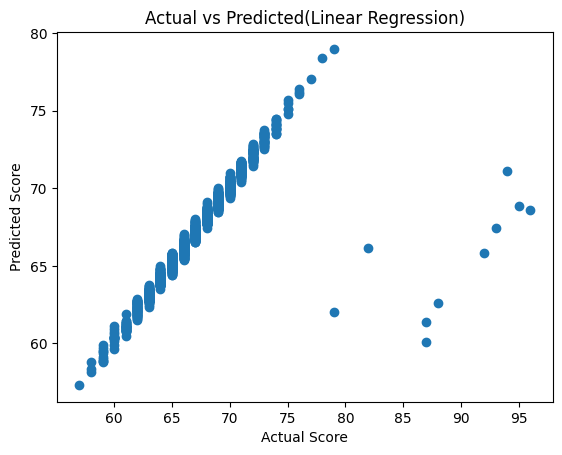

In [ ]:
plt.scatter(y_test,pred_lr)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted(Linear Regression)")
plt.show()

**Feature importance Graph**

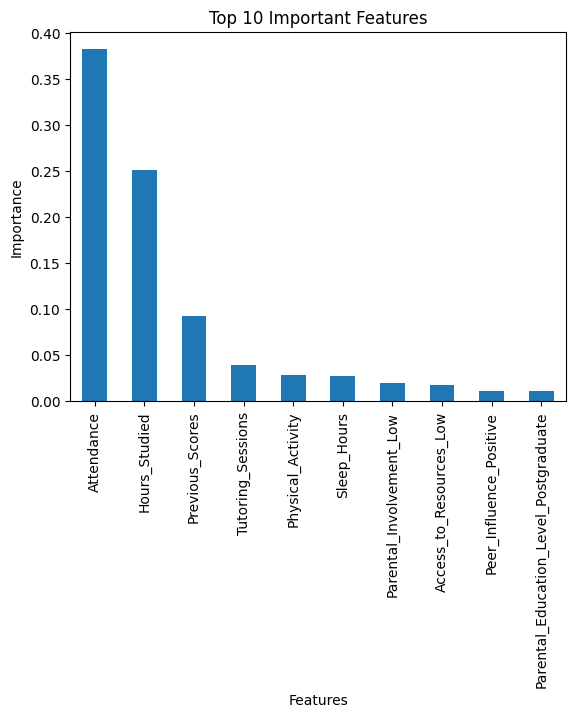

In [ ]:
importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

**Correlation heatmap**

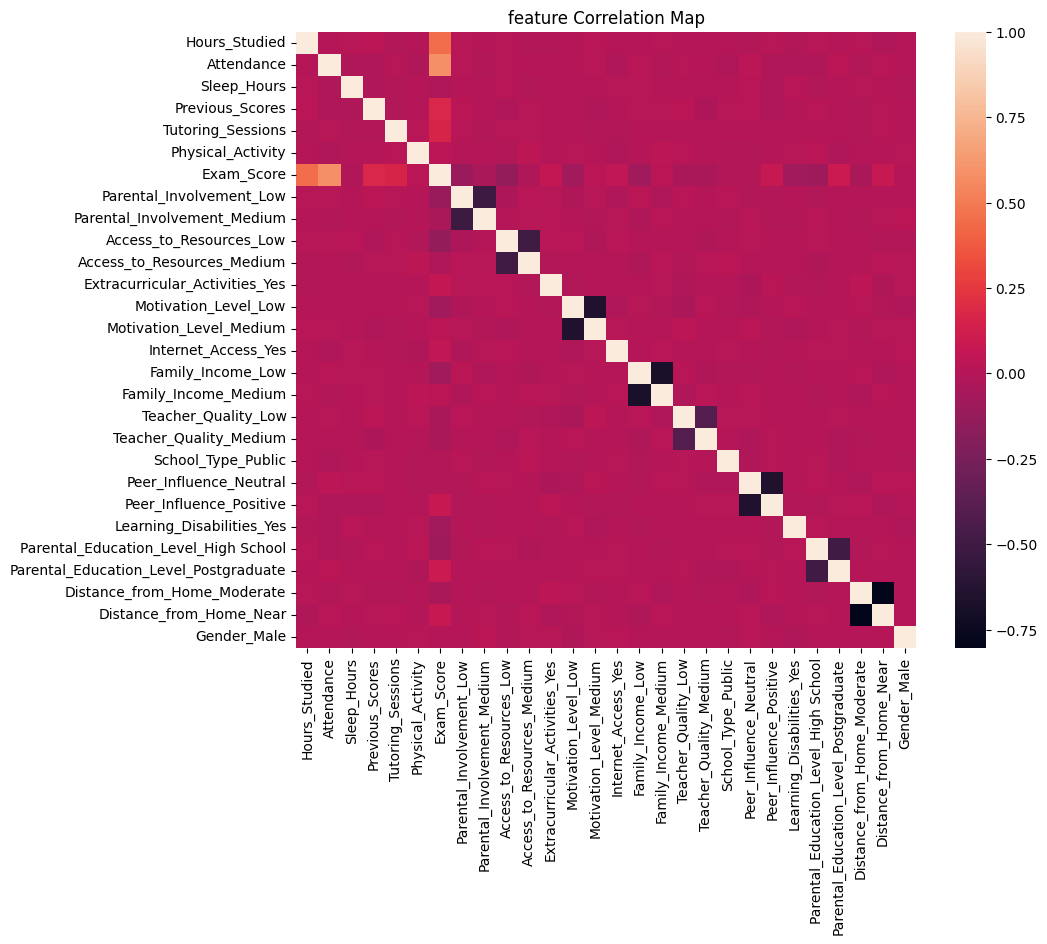

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=False)
plt.title("feature Correlation Map")
plt.show()

**Distribution of Exam score**

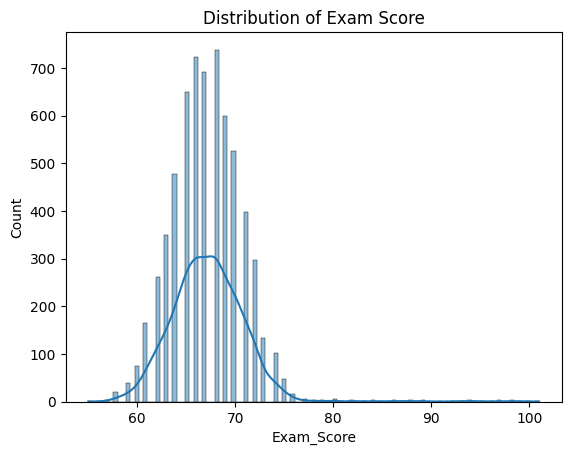

In [ ]:
sns.histplot(df['Exam_Score'],kde=True)
plt.title("Distribution of Exam Score")
plt.show()